In [1]:
import getdist.plots as gdplt
from cobaya import load_samples
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
from scipy.optimize import curve_fit

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)

# looking at distances values on degeneracy line

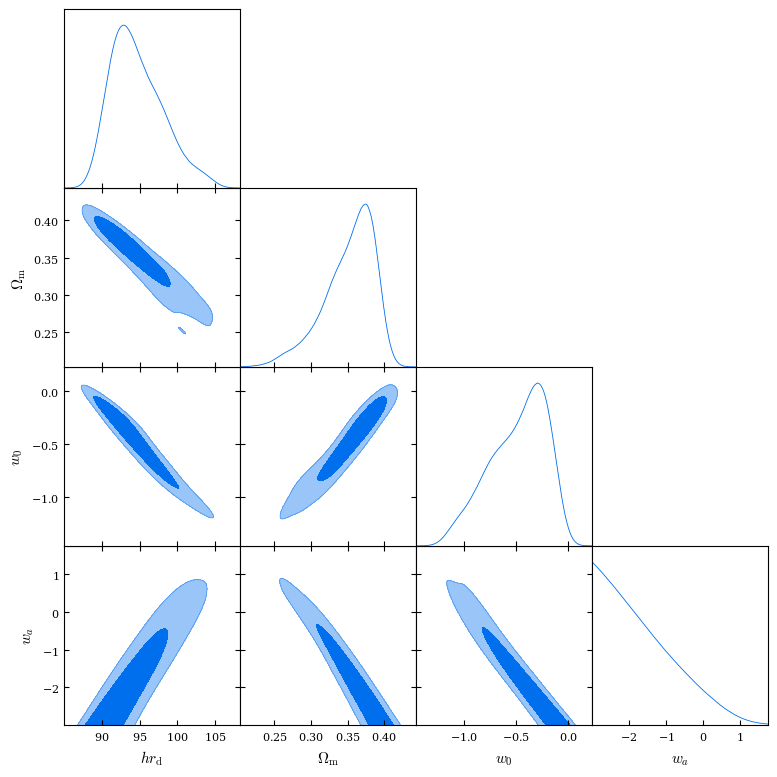

In [2]:
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\base_w_wa\run1'
gd_sample = load_samples(path, to_getdist=True, skip=0.33)
var_names = ['hrdrag', 'omm', 'w', 'wa']
gdplot = gdplt.get_subplot_plotter()
gdplot.triangle_plot(gd_sample, var_names, filled=True)

In [3]:
cov_w_wa = gd_sample.cov(['w', 'wa'])
cov_w_omm = gd_sample.cov(['w', 'omm'])
cov_w_hrd = gd_sample.cov(['w', 'hrdrag'])

cov_mats = [cov_w_wa, cov_w_omm, cov_w_hrd]
means = [gd_sample.mean(['w', 'wa']), gd_sample.mean(['w', 'omm']), gd_sample.mean(['w', 'hrdrag'])]

In [4]:
gauss_cnt = []
slopes = []
intercepts = []
for i in range(len(cov_mats)):
    gauss_cnt.append(np.random.multivariate_normal(mean=means[i], cov=cov_mats[i], size=1000))
    slope, intercept, r_value, p_value, std_err = linregress(gauss_cnt[i][:, 0], gauss_cnt[i][:, 1])
    slopes.append(slope)
    intercepts.append(intercept)

In [5]:
for i in range(len(cov_mats)):
    print(f"Covariance matrix:\n{cov_mats[i]}")
    print(f"Linear relation: y = {slopes[i]:.2f} * x + {intercepts[i]:.2f}\n")

Covariance matrix:
[[ 0.07702357 -0.26349246]
 [-0.26349246  0.97289806]]
Linear relation: y = -3.41 * x + -3.29

Covariance matrix:
[[0.07702357 0.0091789 ]
 [0.0091789  0.00122728]]
Linear relation: y = 0.12 * x + 0.41

Covariance matrix:
[[ 0.07702357 -0.95561753]
 [-0.95561753 12.59235062]]
Linear relation: y = -12.40 * x + 88.78



#### definitions

In [6]:
def expansion_rate(z, Omega_m, Omega_Lambda, w0=-1.0, wa=0): # by default lambdaCDM
    """    
    Parameters:
    z Redshift
    Omega_m Matter density parameter
    Omega_Lambda DE density parameter
    w0 constant equation of state parameter for DE
    wa varying equation of state parameter for DE

    Returns: E(z) = H(z)/H0
    """
    Omega_DE = Omega_Lambda * (1 + z)**(3 * (1 + w0 + wa)) * np.exp(-3 * wa * z / (1 + z))

    Omega_total = Omega_m * (1 + z)**3 + Omega_DE

    E_z = np.sqrt(Omega_total)
    return E_z

def trans_comoving_dist_array(z, par):
    """
    Returns: Transverse comoving distance D_M(z) in units of h^-1 Mpc
    """
    c = 299792.458  # km/s
    from scipy.integrate import quad

    Omega_m, w0, wa = par
    Omega_Lambda = 1 - Omega_m  # Assuming a flat universe

    def integrand(z_prime):
        return 1 / expansion_rate(z_prime, Omega_m, Omega_Lambda, w0, wa)

    # check if z is a scalar or an array
    if np.isscalar(z):
        integral, _ = quad(integrand, 0, z)
        return c/100 * integral
    
    integral1, _ = quad(integrand, 0, z[0])
    integrals = []
    for i in range(len(z)):
        part_int = quad(integrand, z[i-1], z[i])[0] if i > 0 else integral1
        integrals.append(part_int + (integrals[i-1] if i > 0 else 0))
    return [c/100 * el for el in integrals]

def Hubble_dist(z, par):# Omega_m, Omega_Lambda, w0=-1.0, wa=0):
    """
    Returns: Hubble distance D_H(z) in units of h^-1 Mpc
    """
    Omega_m, w0, wa = par
    Omega_Lambda = 1 - Omega_m  # Assuming a flat universe
    c = 299792.458  # km/s
    return c/100 / expansion_rate(z, Omega_m, Omega_Lambda, w0, wa)

# def sound_horizon_approx(par):
#     '''
#     Need par = H0, Omega_m, Omega_b; returns h*r_d with an approximation formula Eq. 3.4 from 2212.04522
#     '''
#     a = -0.23
#     b = -0.1
#     c = -0.13
#     Omega_m, H0 = par
#     Omega_b = 0.02236/(H0/100)**2
#     Neff = 3.04
#     h = H0/100
#     return h * 147.05 * ((Omega_m * h**2)/ 0.1432 )**a * ((Omega_b * h**2)/ 0.02236 )**b * (Neff/ 3.04)**c

# def sound_horizon(par):
#     '''
#     Need par = H0, Omega_m, Omega_b; returns h*r_d
#     '''
#     H0, Om, Ob, w0, wa = par
#     h = H0/100
#     params = camb.CAMBparams()
#     params.set_cosmology(H0=H0, ombh2=(Ob*h**2), omch2=((Om-Ob)*h**2), mnu=0.06, omk=0, tau=0.06)
#     params.WantTransfer = False
#     params.WantTensors = False
#     params.WantDerivedParameters  = False
#     params.Want_cl_2D_array = False
#     params.Want_CMB_lensing = False
#     params.DoLensing = False
#     params.want_zdrag  = False
#     params.want_zstar  = False

#     params.set_dark_energy(w=w0, wa=wa, dark_energy_model='ppf')
#     results = camb.get_results(params)

#     return results.sound_horizon(1060) * h

def compute_DV(z, par):
    '''
    Returns D_V(z) in units of h^-1 Mpc, D_V = (z * D_M^2(z) * D_H(z))^(1/3)
    '''
    DM = trans_comoving_dist_array(z, par)
    DH = Hubble_dist(z, par)
    return (z * DM**2 * DH)**(1/3)

## degeneracy lines 

In [7]:
gd_sample = load_samples(r'..\..\cobaya_runs\DESI_data\base_w_wa\run1', to_getdist=True, skip=0.33) # DESI all z run using w0waCDM

var_names = ['w', 'wa']

In [8]:
# Get covariance matrix for w0 and wa
cov = gd_sample.cov(pars=['w', 'wa'])
mean_w  = gd_sample.mean('w')
mean_wa = gd_sample.mean('wa')

In [9]:
# gaussian grid centered on mean
gaussian_grid = np.random.multivariate_normal(mean=[mean_w, mean_wa], cov=cov, size=10000)

In [10]:
# # linear fit on the points
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(gaussian_grid[:, 0], gaussian_grid[:, 1])
# print("slope:", slope)

from scipy.optimize import curve_fit
def linear_model(x, a):
    return a * (x + 1) 

popt, pcov = curve_fit(linear_model, gaussian_grid[:, 0], gaussian_grid[:, 1])
print("optimal parameter:", popt[0])

optimal parameter: -3.2413051751221182


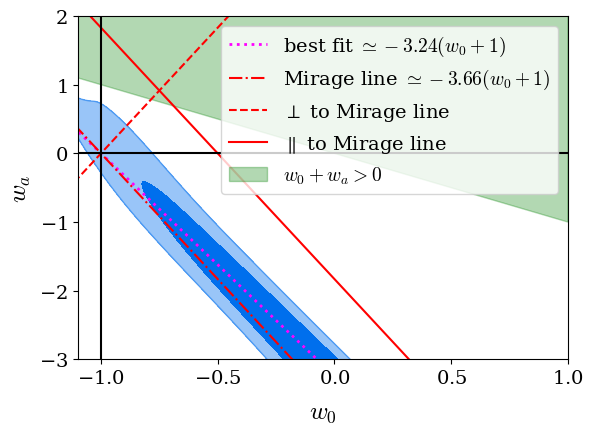

In [11]:
gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
gdplot.settings.axes_fontsize = 14
gdplot.plot_2d(gd_sample, var_names[0], var_names[1], filled=True)
# plt.scatter(gaussian_grid[:, 0], gaussian_grid[:, 1], s=1, alpha=0.5, color='r')

x_fit = np.linspace(-2, 1, 100)
y_fit = slope * x_fit + intercept   
# plt.plot(x_fit, y_fit, color='k', ls='--', label='linear fit')
y_fit = popt[0] * (x_fit + 1)
plt.plot(x_fit, y_fit, color='magenta', ls=':', label=rf'best fit $\simeq {popt[0]:.2f} (w_0 + 1)$', lw=2)
y_fit = -2.85 * x_fit - 2.92
# plt.plot(x_fit, y_fit, color='r', ls=':', label='CMB+BAO')
y_fit = -3.66 * (x_fit + 1)
plt.plot(x_fit, y_fit, color='r', ls='-.', label=r'Mirage line $\simeq -3.66 (w_0 + 1)$')
y_fit = 3.66 * (x_fit + 1)
plt.plot(x_fit, y_fit, color='r', ls='--', label=r'$\perp$ to Mirage line')
y_fit = -3.66 * (x_fit + 0.5)
plt.plot(x_fit, y_fit, color='r', ls='-', label=r'$\parallel$ to Mirage line')

y_fit = -x_fit
plt.fill_between(x_fit, y_fit, 2, color='g', alpha=0.3, label=r'$w_0+w_a > 0$')
# plt.plot(x_fit, y_fit, color='g', ls='-', label=r'$w_0+w_a < 0$')

plt.axhline(0, color='k', ls='-')
plt.axvline(-1, color='k', ls='-')

plt.xlim(-1.1, 1.0)
plt.ylim(-3, 2.0)
plt.legend()


# print("degeneracy line : wa =", round(slope, 1), "* w0 +", round(intercept, 1))

In [12]:
def distances_ratio(slope, offset=1):
    '''calcul wa
    puis suivant une certaine méthode Om et hrdrag
    puis les observables
    puis redonne un tableau de valeur DM/DH pour chaque ligne et chaque redshift donc si 3 lignes : 3 x 6'''
    w0 = np.linspace(-1, 0, 100)
    wa = slope * ( w0 + offset)
    Omegam = slopes[1] * w0 + intercepts[1]
    hrdrag = slopes[2] * w0 + intercepts[2]

    z = [0.510, 0.706, 0.934, 1.321, 1.484, 2.330]

    DM = [trans_comoving_dist_array(z, [Omegam[i], w0[i], wa[i]]) for i in range(len(w0))]
    DM = np.array(DM)
    DMover_rd = np.zeros(DM.shape)
    for i in range(len(w0)):
        DMover_rd[i] = [DM[i][j]/hrdrag[i] for j in range(len(z))]

    DHover_rd = np.zeros(DM.shape)
    for i in range(len(w0)):
        DHover_rd[i] = [Hubble_dist(z[j], [Omegam[i], w0[i], wa[i]])/hrdrag[i] for j in range(len(z))]  
    DMoverDH = np.zeros(DM.shape)
    for i in range(len(w0)):
        DMoverDH[i] = [DM[i][j]/Hubble_dist(z[j], [Omegam[i], w0[i], wa[i]]) for j in range(len(z))]
    DVover_rd = np.zeros(DM.shape)
    for i in range(len(w0)):
        DVover_rd[i] = [compute_DV(z[j], [Omegam[i], w0[i], wa[i]])/hrdrag[i] for j in range(len(z))]

    return DMoverDH, DVover_rd, w0

### cosmoprimo $\alpha_\perp, \ \alpha_\parallel$

#### test

In [13]:
import cosmoprimo

# help(cosmoprimo.cosmology.Cosmology)

In [14]:
cosmo = cosmoprimo.Cosmology()
print(cosmo._params)  # see what got set by default

{'h': array(0.7), 'Omega_cdm': array(0.25), 'Omega_b': array(0.05), 'Omega_k': 0.0, 'sigma8': array(0.8), 'k_pivot': 0.05, 'n_s': 0.96, 'alpha_s': 0.0, 'beta_s': 0.0, 'r': 0.0, 'n_t': -0.0, 'alpha_t': -0.0, 'T_cmb': array(2.7255), 'T_ncdm_over_cmb': array([], dtype=float64), 'tau_reio': 0.06, 'reionization_width': 0.5, 'A_L': 1.0, 'w0_fld': array(-1.), 'wa_fld': array(0.), 'cs2_fld': array(1.), 'non_linear': '', 'modes': ['s'], 'lensing': False, 'z_pk': array([ 0.        ,  0.01189061,  0.04756243,  0.10701546,  0.1902497 ,
        0.29726516,  0.42806183,  0.58263971,  0.76099881,  0.96313912,
        1.18906064,  1.43876338,  1.71224732,  2.00951249,  2.33055886,
        2.67538644,  3.04399524,  3.43638526,  3.85255648,  4.29250892,
        4.75624257,  5.24375743,  5.75505351,  6.2901308 ,  6.8489893 ,
        7.43162901,  8.03804994,  8.66825208,  9.32223543, 10.        ]), 'kmax_pk': 10.0, 'ellmax_cl': 2500, 'YHe': 'BBN', 'use_ppf': True, 'N_ur': array(3.044), 'm_ncdm': array([],

In [15]:
planck_cosmo = cosmoprimo.fiducial.Planck2018FullFlatLCDM()
print(planck_cosmo._params)

{'k_pivot': 0.05, 'alpha_s': 0.0, 'beta_s': 0.0, 'r': 0.0, 'n_t': -0.0, 'alpha_t': -0.0, 'T_cmb': array(2.7255), 'T_ncdm_over_cmb': array([0.71611]), 'reionization_width': 0.5, 'A_L': 1.0, 'cs2_fld': array(1.), 'non_linear': '', 'modes': ['s'], 'lensing': False, 'z_pk': array([ 0.        ,  0.01189061,  0.04756243,  0.10701546,  0.1902497 ,
        0.29726516,  0.42806183,  0.58263971,  0.76099881,  0.96313912,
        1.18906064,  1.43876338,  1.71224732,  2.00951249,  2.33055886,
        2.67538644,  3.04399524,  3.43638526,  3.85255648,  4.29250892,
        4.75624257,  5.24375743,  5.75505351,  6.2901308 ,  6.8489893 ,
        7.43162901,  8.03804994,  8.66825208,  9.32223543, 10.        ]), 'kmax_pk': 10.0, 'ellmax_cl': 2500, 'YHe': 'BBN', 'use_ppf': True, 'h': array(0.6766), 'Omega_k': 0.0, 'sigma8': array(0.8102), 'n_s': 0.9665, 'tau_reio': 0.0561, 'w0_fld': array(-1.), 'wa_fld': array(0.), 'Omega_cdm': array(0.26066676), 'Omega_b': array(0.04897468), 'N_ur': array(2.03079837), 

In [16]:
planck_cosmo = cosmoprimo.fiducial.Planck2018FullFlatLCDM()
p = planck_cosmo._params

# DESI DR2 best fit Omega_m = 0.2975
# Omega_m = Omega_cdm + Omega_b, so adjust Omega_cdm accordingly
Omega_cdm = p['Omega_cdm']
Omega_b = p['Omega_b']
Omega_cdm_DESI = 0.2975 - Omega_b
print(Omega_cdm + Omega_b)
print(Omega_cdm_DESI + Omega_b)

desi_cosmo = cosmoprimo.Cosmology(
    h=p['h'],
    Omega_cdm=Omega_cdm_DESI,
    Omega_b=Omega_b,
    n_s=p['n_s'],
    sigma8=p['sigma8'],
    w0_fld=-1.0,
    wa_fld=0.0,
)

0.30964144154550644
0.2975


#### imitate fig 6 of DESI paper

In [17]:
def alpha_perp_parallel(z, cosmo_params):
    '''
    alpha_perp = (DM(z)/rd) / (DM_fid(z)/rd_fid)
    alpha_parallel = (DH(z)/rd) / (DH_fid(z)/rd_fid)
    fid --> either LCDM best fit or Planck
    '''

    planck_cosmo = cosmoprimo.fiducial.Planck2018FullFlatLCDM()
    p = planck_cosmo._params

    # DESI DR2 best fit Omega_m = 0.2975
    # Omega_m = Omega_cdm + Omega_b, so adjust Omega_cdm accordingly
    Omega_b = p['Omega_b']
    Omega_cdm_DESI = 0.2975 - Omega_b

    desi_cosmo = cosmoprimo.fiducial.DESI(Omega_cdm=Omega_cdm_DESI, engine='camb')

    # fid_planck = cosmoprimo.Cosmology(Omega_m=0.2975, Omega_b=Omega_b, w=-1.0, wa=0.0, h=h)
    fid_planck = desi_cosmo.copy()
    fid_bkg = fid_planck.get_background(engine='camb')
    # fid_thermo = fid_planck.get_thermodynamics()
    # rdrag_fid = fid_thermo.rs_drag
    rdrag_fid = 101.54

    DM_fid = fid_bkg.comoving_angular_distance(z)
    DH_fid = 1 / fid_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (z * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid


    real_cosmo = planck_cosmo.copy()
    print(real_cosmo['Omega_b'], real_cosmo['h'])
    real_bkg = real_cosmo.get_background(engine='camb')
    real_thermo = real_cosmo.get_thermodynamics()
    rdrag_real = real_thermo.rs_drag
    DM_real = real_bkg.comoving_angular_distance(z)
    DH_real = 1 / real_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_real = (z * DM_real**2 * DH_real)**(1/3)
    DMover_rd_real = DM_real / rdrag_real
    DHover_rd_real = DH_real / rdrag_real
    DVover_rd_real = DV_real / rdrag_real
    
    return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid

0.04897468161869667 0.6766


C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\3582976426.py:45: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


(0.94, 1.06)

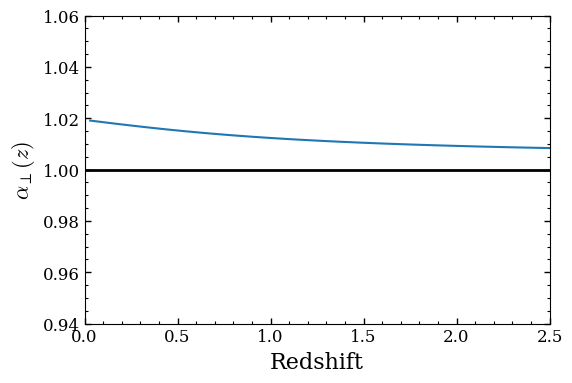

In [18]:
from matplotlib.ticker import AutoMinorLocator

z = np.linspace(0.0, 3.0, 100)
a, b, c = alpha_perp_parallel(z, (-1.0, 0.0, 0.2975, 100, 0.6766))

plt.figure(figsize=(6, 4))
plt.plot(z, a)

ax = plt.gca()
ax.tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.xlabel('Redshift')
plt.ylabel(r'$\alpha_\perp(z)$')
plt.axhline(1, color='k', ls='-', lw=2)
plt.xlim(0, 2.5)
plt.ylim(0.94, 1.06)

(0.9, 1.05)

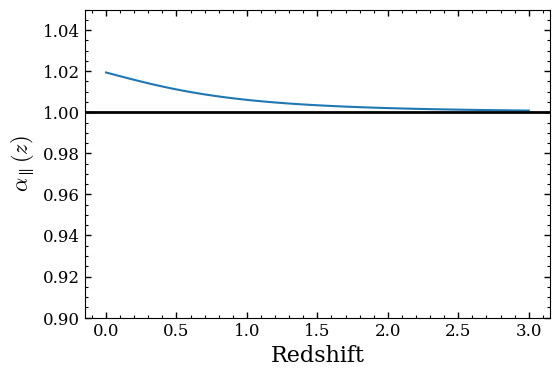

In [19]:
plt.figure(figsize=(6, 4))
plt.plot(z, b)

ax = plt.gca()
ax.tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.xlabel('Redshift')
plt.ylabel(r'$\alpha_\parallel(z)$')
plt.axhline(1, color='k', ls='-', lw=2)
# plt.xlim(0, 2.5)
plt.ylim(0.9, 1.050)

#### gradient of $w_0$ on Mirage line and other lines

In [20]:
def alpha_perp_parallel(z, cosmo_params):
    '''
    alpha_perp = (DM(z)/rd) / (DM_fid(z)/rd_fid)
    alpha_parallel = (DH(z)/rd) / (DH_fid(z)/rd_fid)
    fid --> either LCDM best fit or Planck
    '''
    fid_planck = cosmoprimo.fiducial.Planck2018FullFlatLCDM()
    fid_bkg = fid_planck.get_background(engine='camb')
    fid_thermo = fid_planck.get_thermodynamics()
    rdrag_fid = fid_thermo.rs_drag
    DM_fid = fid_bkg.comoving_angular_distance(z)
    DH_fid = 1 / fid_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (z * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid

###########################################################
    w0, wa, Omegam, hrdrag = cosmo_params
    
    Omega_b = planck_cosmo['Omega_b']
    Omega_cdm_new = Omegam - Omega_b

    real_cosmo = cosmoprimo.Cosmology(Omega_cdm=Omega_cdm_new, w=w0, wa=wa)
    # print(real_cosmo['h'], real_cosmo['Omega_cdm'], real_cosmo['Omega_m'], real_cosmo['Omega_b'], real_cosmo['w0_fld'], real_cosmo['wa_fld'])
    real_bkg = real_cosmo.get_background(engine='camb')
    # real_thermo = real_cosmo.get_thermodynamics()
    # rdrag_real = real_thermo.rs_drag
    DM_real = real_bkg.comoving_angular_distance(z)
    DH_real = 1 / real_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_real = (z * DM_real**2 * DH_real)**(1/3)
    DMover_rd_real = DM_real / hrdrag
    DHover_rd_real = DH_real / hrdrag
    DVover_rd_real = DV_real / hrdrag
    
    return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid
    # return DMover_rd_real, DMover_rd_fid, DHover_rd_real, DHover_rd_fid, DVover_rd_real, DVover_rd_fid

In [21]:
from matplotlib.ticker import AutoMinorLocator
import matplotlib.cm as cm
import matplotlib.colors as mcolors

z = np.linspace(0.0, 3.0, 100)
# a, b, c = alpha_perp_parallel(z, (-1.0, 0.0, 0.2975, 100))

w0 = np.linspace(-1, 0, 20)
offset = 1
slope = -3.66

alph_perp = []
alph_par = []

for i in range(len(w0)):
    wa = slope * ( w0[i] + offset)
    Omegam = slopes[1] * w0[i] + intercepts[1]
    hrdrag = slopes[2] * w0[i] + intercepts[2]
    a, b, _ = alpha_perp_parallel(z, (w0[i], wa, Omegam, hrdrag))
    alph_perp.append(a)
    alph_par.append(b)
    # aperp, aperp_fid, apar, apar_fid, _, _ = alpha_perp_parallel(z, (w0[i], wa, Omegam, hrdrag))
    # alph_perp.append(aperp/aperp_fid)
    # alph_par.append(apar/apar_fid)
    if i == 0:
        print(f"w0: {w0[i]:.2f}, wa: {wa:.2f}, Omegam: {Omegam:.3f}, hrdrag: {hrdrag:.2f}")

C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\526168662.py:36: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


w0: -1.00, wa: -0.00, Omegam: 0.290, hrdrag: 101.19


20


(0.0, 2.5)

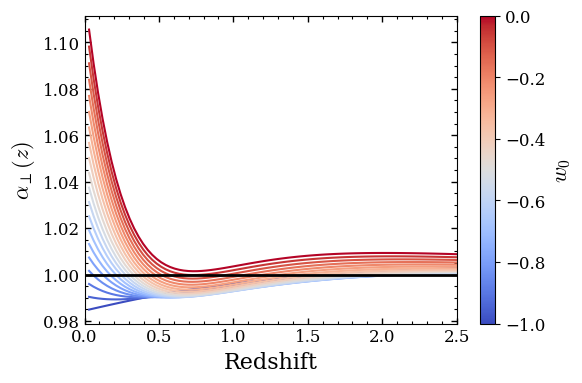

In [22]:
# define colormap and normalisation
cmap = cm.coolwarm  # or any other: viridis, plasma, RdBu, etc.
norm = mcolors.Normalize(vmin=w0.min(), vmax=w0.max())

fig, ax = plt.subplots(figsize=(6, 4))

print(len(w0))
mask = 20
for i in range(len(w0[:mask])):
    ax.plot(z, alph_perp[i], color=cmap(norm(w0[i])))

# colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'$w_0$')

ax.tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.xlabel('Redshift')
plt.ylabel(r'$\alpha_\perp(z)$')
plt.axhline(1, color='k', ls='-', lw=2)
plt.xlim(0, 2.5)
# plt.ylim(0.94, 1.06)

20


(0.0, 2.5)

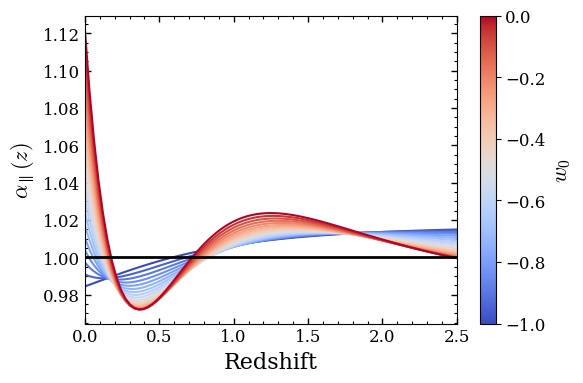

In [23]:
# define colormap and normalisation
cmap = cm.coolwarm  # or any other: viridis, plasma, RdBu, etc.
norm = mcolors.Normalize(vmin=w0.min(), vmax=w0.max())

fig, ax = plt.subplots(figsize=(6, 4))

print(len(w0))
mask = 20
for i in range(len(w0[:mask])):
    # a_perp_inv = [1/val for val in alph_perp[i]]
    ax.plot(z, alph_par[i], color=cmap(norm(w0[i])))
    # ax.plot(z, a_perp_inv, color=cmap(norm(w0[i])))

# colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label=r'$w_0$')

ax.tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.xlabel('Redshift')
plt.ylabel(r'$\alpha_\parallel(z)$')
plt.axhline(1, color='k', ls='-', lw=2)
plt.xlim(0, 2.5)
# plt.ylim(0.94, 1.06)

##### for different lines

In [24]:
from matplotlib.offsetbox import AnchoredText

def plot_alpha_ratios(z, w0, slope, offset):
    alph_perp = []
    alph_par = []
    alph_AP = []
    alph_ISO = []

    for i in range(len(w0)):
        wa = slope * ( w0[i] + offset)
        Omegam = slopes[1] * w0[i] + intercepts[1]
        hrdrag = slopes[2] * w0[i] + intercepts[2]
        a, b, c = alpha_perp_parallel(z, (w0[i], wa, Omegam, hrdrag))
        alph_perp.append(a)
        alph_par.append(b)
        alph_AP.append(b/a)
        alph_ISO.append(c)

    cmap = cm.coolwarm  # or any other: viridis, plasma, RdBu, etc.
    norm = mcolors.Normalize(vmin=w0.min(), vmax=w0.max())

    fig, ax = plt.subplots(figsize=(6, 4))

    print(len(w0))
    mask = 20
    for i in range(len(w0[:mask])):
        ax.plot(z, alph_perp[i], color=cmap(norm(w0[i])))

    # colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=r'$w_0$')

    ax.tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
    ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())


    text = AnchoredText(rf'$w_a = {slope:.2f}(w_0 + {offset:.1f})$', 
                        loc='upper right', frameon=True,
                        prop=dict(size=14))
    ax.add_artist(text)

    plt.xlabel('Redshift')
    plt.ylabel(r'$\alpha_\perp(z)$')
    plt.axhline(1, color='k', ls='-', lw=2)

    cmap = cm.coolwarm  # or any other: viridis, plasma, RdBu, etc.
    norm = mcolors.Normalize(vmin=w0.min(), vmax=w0.max())

    fig, ax = plt.subplots(figsize=(6, 4))

    print(len(w0))
    mask = 20
    for i in range(len(w0[:mask])):
        # a_perp_inv = [1/val for val in alph_perp[i]]
        ax.plot(z, alph_par[i], color=cmap(norm(w0[i])))
        # ax.plot(z, a_perp_inv, color=cmap(norm(w0[i])))

    # colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=r'$w_0$')

    ax.tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
    ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    
    text = AnchoredText(rf'$w_a = {slope:.2f}(w_0 + {offset:.1f})$', 
                        loc='upper right', frameon=True,
                        prop=dict(size=14))
    ax.add_artist(text)

    plt.xlabel('Redshift', fontsize=16)
    plt.ylabel(r'$\alpha_\parallel(z)$', fontsize=16)
    plt.axhline(1, color='k', ls='-', lw=2)
    # plt.xlim(0, 2.5)
    # plt.ylim(0.94, 1.06)

    fig, ax = plt.subplots(figsize=(6, 4))

    print(len(w0))
    mask = 20
    for i in range(len(w0[:mask])):
        # a_perp_inv = [1/val for val in alph_perp[i]]
        ax.plot(z, alph_AP[i], color=cmap(norm(w0[i])))
        # ax.plot(z, a_perp_inv, color=cmap(norm(w0[i])))

    # colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=r'$w_0$')

    ax.tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
    ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    
    text = AnchoredText(rf'$w_a = {slope:.2f}(w_0 + {offset:.1f})$', 
                        loc='lower right', frameon=True,
                        prop=dict(size=14))
    ax.add_artist(text)

    plt.xlabel('Redshift', fontsize=16)
    plt.ylabel(r'$\alpha_\mathrm{AP}(z)$', fontsize=16)
    plt.axhline(1, color='k', ls='-', lw=2)

    fig, ax = plt.subplots(figsize=(6, 4))

    print(len(w0))
    mask = 20
    for i in range(len(w0[:mask])):
        # a_perp_inv = [1/val for val in alph_perp[i]]
        ax.plot(z, alph_ISO[i], color=cmap(norm(w0[i])))
        # ax.plot(z, a_perp_inv, color=cmap(norm(w0[i])))

    # colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=r'$w_0$')

    ax.tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
    ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    
    text = AnchoredText(rf'$w_a = {slope:.2f}(w_0 + {offset:.1f})$', 
                        loc='upper right', frameon=True,
                        prop=dict(size=14))
    ax.add_artist(text)

    plt.xlabel('Redshift', fontsize=16)
    plt.ylabel(r'$\alpha_\mathrm{ISO}(z)$', fontsize=16)
    plt.axhline(1, color='k', ls='-', lw=2)

C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\526168662.py:36: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


20
20
20
20


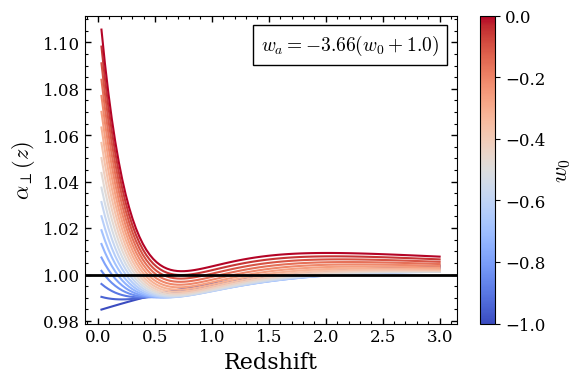

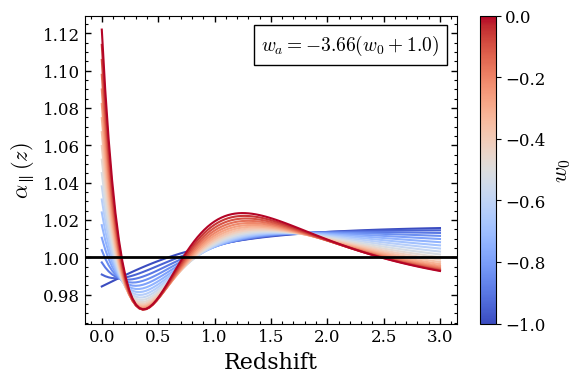

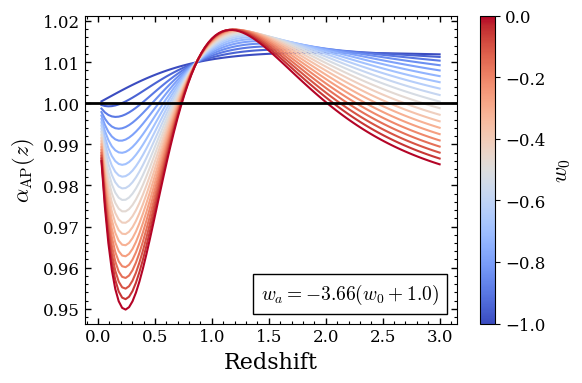

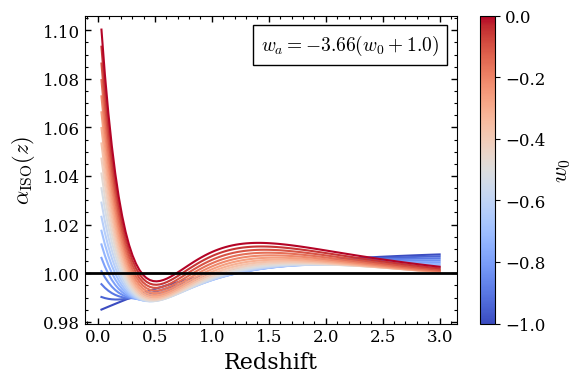

In [25]:
z = np.linspace(0.0, 3.0, 100)
# a, b, c = alpha_perp_parallel(z, (-1.0, 0.0, 0.2975, 100))

w0 = np.linspace(-1, 0, 20)
offset = 1
slope = -3.66

plot_alpha_ratios(z, w0, slope, offset)

[np.float64(-0.2680000000000001), np.float64(-0.40800000000000003), np.float64(-0.5480000000000002), np.float64(-0.6880000000000003), np.float64(-0.8280000000000002), np.float64(-0.968), np.float64(-1.108), np.float64(-1.2480000000000002), np.float64(-1.3880000000000001), np.float64(-1.528), np.float64(-1.6680000000000001), np.float64(-1.8080000000000003), np.float64(-1.9480000000000002), np.float64(-2.088), np.float64(-2.228), np.float64(-2.3680000000000003), np.float64(-2.508), np.float64(-2.6479999999999997), np.float64(-2.7880000000000003), np.float64(-2.9280000000000004)]


C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\526168662.py:36: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


20
20
20
20


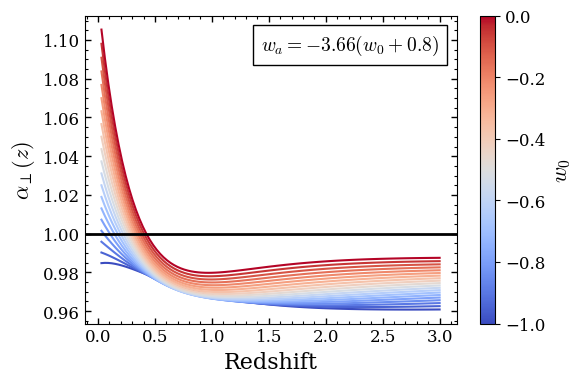

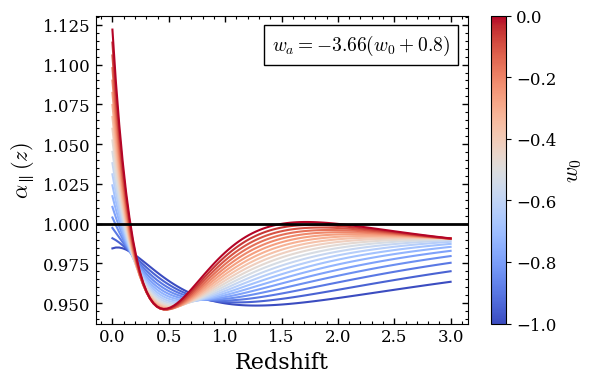

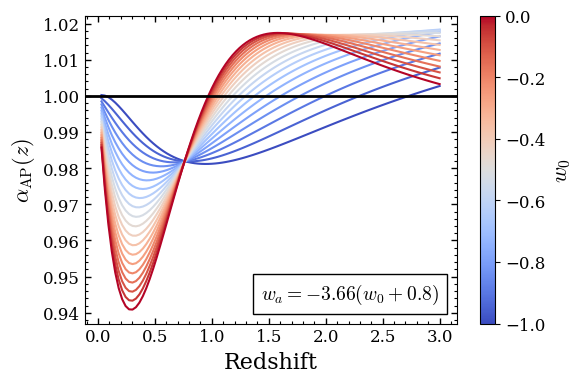

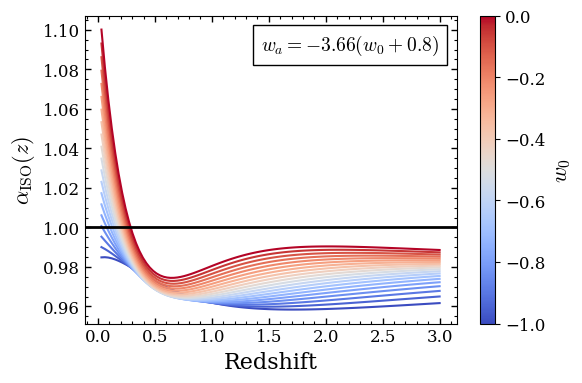

In [26]:
slope = -3.66
offset = 0.8
wa_ = slope * ( w0 + offset)
print([wa_[i] + w0[i] for i in range(len(w0))])

plot_alpha_ratios(z, w0, slope, offset)

#### imitate Fig 13

In [27]:
path = r'..\..\DESI_DR2_chains\base_w_wa\desi-bao-all_desy5sn_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing\chain'
path2 = r'..\..\DESI_DR2_chains\base\desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE\chain'
path3 = r'..\..\DESI_DR2_chains\base\desy5sn\chain'
gd_sample = load_samples(path, to_getdist=True, skip=0.33)
gd_sample2 = load_samples(path2, to_getdist=True, skip=0.33)
gd_sample3 = load_samples(path3, to_getdist=True, skip=0.33)

In [28]:
var_names = ['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'w', 'wa']
var_names = ['ombh2', 'omch2', 'w', 'wa']

# gdplot = gdplt.get_subplot_plotter()
# gdplot.triangle_plot(gd_sample, var_names, filled=True)

In [29]:
mean_w  = gd_sample.mean('w')           # this is w0 wa with DESI+CMB+DESY5
mean_wa = gd_sample.mean('wa')
mean_ombh2 = gd_sample.mean('ombh2')
mean_omch2 = gd_sample.mean('omch2')
mean_H0 = gd_sample.mean('H0')
mean_rdrag = gd_sample.mean('rdrag')

mean_ombh2_2 = gd_sample2.mean('ombh2') # this is LCDM DESI+CMB
mean_omch2_2 = gd_sample2.mean('omch2')
mean_H0_2 = gd_sample2.mean('H0')
mean_rdrag_2 = gd_sample2.mean('rdrag')

mean_omm_3 = gd_sample3.mean('omm') # this is LCDM DESI+DESY5

print(f"mean w: {mean_w:.2f}, mean wa: {mean_wa:.2f}, mean ombh2: {mean_ombh2:.5f}, mean omch2: {mean_omch2:.5f}, mean H0: {mean_H0:.2f}")

cov = gd_sample.cov(pars=['w', 'wa'])

gaussian_grid = np.random.multivariate_normal(mean=[mean_w, mean_wa], cov=cov, size=10000)
from scipy.optimize import curve_fit
def f(x, a):
    return a * (x + 1)
popt, pcov = curve_fit(f, gaussian_grid[:, 0], gaussian_grid[:, 1])
print("optimal parameter:", popt[0])

mean w: -0.75, mean wa: -0.86, mean ombh2: 0.02223, mean omch2: 0.11921, mean H0: 66.74
optimal parameter: -3.481349507745893


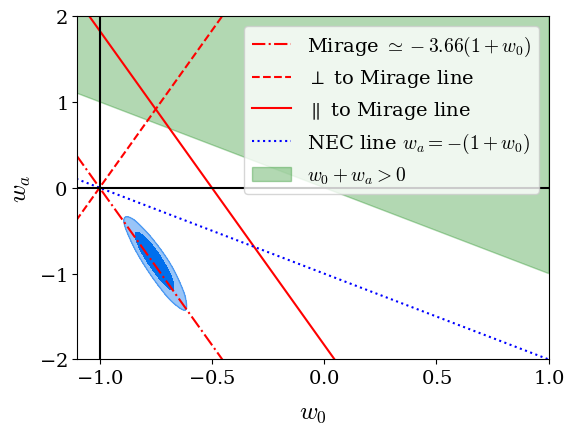

In [30]:
gdplot = gdplt.get_single_plotter()
gdplot.settings.axes_labelsize = 18
gdplot.settings.axes_fontsize = 14

gdplot.plot_2d(gd_sample, 'w', 'wa', filled=True)

# grab the axes getdist created
ax = gdplot.get_axes()  # or plt.gca()

x_fit = np.linspace(-2, 1, 100)

y_fit = -3.66 * (x_fit + 1)
ax.plot(x_fit, y_fit, color='r', ls='-.', label=r'Mirage $\simeq -3.66 (1 + w_0)$')
y_fit = 3.66 * (x_fit + 1)
ax.plot(x_fit, y_fit, color='r', ls='--', label=r'$\perp$ to Mirage line')
y_fit = -3.66 * (x_fit + 0.5)
ax.plot(x_fit, y_fit, color='r', ls='-', label=r'$\parallel$ to Mirage line')
y_fit = -1.0 * (x_fit + 1.0)
ax.plot(x_fit, y_fit, color='b', ls=':', label=r'NEC line $w_a = - (1 + w_0)$')

y_fit = -x_fit
ax.fill_between(x_fit, y_fit, 3, color='g', alpha=0.3, label=r'$w_0+w_a > 0$')
# ax.plot(x_fit, y_fit, color='g', ls='-', label=r'$w_0+w_a < 0$')

ax.axhline(0, color='k', ls='-')
ax.axvline(-1, color='k', ls='-')

ax.set_xlim(-1.1, 1.0)
ax.set_ylim(-2, 2.0)
ax.legend()

fig = gdplot.fig  # grab the figure if needed for saving
# fig.savefig(r'..\..\figures\degen_line\w_wa_contour.png', dpi=300)

In [31]:
def alpha_perp_parallel_alt(z, cosmo_params):
    '''
    alpha_perp = (DM(z)/rd) / (DM_fid(z)/rd_fid)
    alpha_parallel = (DH(z)/rd) / (DH_fid(z)/rd_fid)
    fid --> flat Planck 2018 LCDM
    '''
    fid_planck = cosmoprimo.fiducial.Planck2018FullFlatLCDM()
    fid_bkg = fid_planck.get_background(engine='camb')
    fid_thermo = fid_planck.get_thermodynamics()
    rdrag_fid = fid_thermo.rs_drag
    DM_fid = fid_bkg.comoving_angular_distance(z)
    DH_fid = 1 / fid_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (z * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid

###########################################################
    w0, wa, obh2, och2, h, hrdrag = cosmo_params
    # Omega_cdm_new = och2 / h**2
    # Omega_b_new = obh2 / h**2

    real_cosmo = cosmoprimo.Cosmology(omega_cdm=och2, omega_b=obh2, w=w0, wa=wa, h=h)
    # print(real_cosmo._params)
    # print(real_cosmo['h'], real_cosmo['Omega_cdm'], real_cosmo['Omega_m'], real_cosmo['Omega_b'], real_cosmo['w0_fld'], real_cosmo['wa_fld'])
    real_bkg = real_cosmo.get_background(engine='camb')
    # real_thermo = real_cosmo.get_thermodynamics()
    # rdrag_real = real_thermo.rs_drag
    DM_real = real_bkg.comoving_angular_distance(z)
    DH_real = 1 / real_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_real = (z * DM_real**2 * DH_real)**(1/3)
    DMover_rd_real = DM_real / hrdrag
    DHover_rd_real = DH_real / hrdrag
    DVover_rd_real = DV_real / hrdrag
    
    return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid
    # return DMover_rd_real, DMover_rd_fid, DHover_rd_real, DHover_rd_fid, DVover_rd_real, DVover_rd_fid

In [32]:
from matplotlib.offsetbox import AnchoredText

alph_perp = []
alph_par = []
alph_AP = []
alph_ISO = []

z = np.linspace(0.0, 3.0, 1000)

w0 = mean_w
wa = mean_wa
obh2 = mean_ombh2
och2 = mean_omch2
h = mean_H0/100
hrdrag = mean_rdrag*h

print(f"w0: {w0:.2f}, wa: {wa:.2f}, obh2: {obh2:.5f}, och2: {och2:.5f}, h: {h:.3f}, hrdrag: {hrdrag:.2f}")
# Omegam = slopes[1] * w0[i] + intercepts[1]
# hrdrag = slopes[2] * w0[i] + intercepts[2]
a, b, c = alpha_perp_parallel_alt(z, (w0, wa, obh2, och2, h, hrdrag))
alph_perp.append(a)
alph_par.append(b)
alph_AP.append(b/a)
alph_ISO.append(c)

w0 = -1.0
wa = 0.0
obh2 =  mean_ombh2_2
och2 = mean_omch2_2
h = mean_H0_2/100
hrdrag = mean_rdrag_2*h
a, b, c = alpha_perp_parallel_alt(z, (w0, wa, obh2, och2, h, hrdrag))
alph_perp.append(a)
alph_par.append(b)
alph_AP.append(b/a)
alph_ISO.append(c)


# for DESY5 we only have omega_m and we'll set a value of hrdrag
fid_planck = cosmoprimo.fiducial.Planck2018FullFlatLCDM()
fid_bkg = fid_planck.get_background(engine='camb')
fid_thermo = fid_planck.get_thermodynamics()
rdrag_fid = fid_thermo.rs_drag
DM_fid = fid_bkg.comoving_angular_distance(z)
DH_fid = 1 / fid_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
DV_fid = (z * DM_fid**2 * DH_fid)**(1/3)
DMover_rd_fid = DM_fid / rdrag_fid
DHover_rd_fid = DH_fid / rdrag_fid
DVover_rd_fid = DV_fid / rdrag_fid
w0 = -1.0
wa = 0.0
omm =  mean_omm_3
DM_desy5 = trans_comoving_dist_array(z, [omm, w0, wa])
DH_desy5 = Hubble_dist(z, [omm, w0, wa])
DV_desy5 = [compute_DV(red, [omm, w0, wa]) for red in z]
rdrag_fid = 98.1
DMover_rd_desy5 = [d / rdrag_fid for d in DM_desy5]
DHover_rd_desy5 = [d / rdrag_fid for d in DH_desy5]
DVover_rd_desy5 = [d / rdrag_fid for d in DV_desy5]
alph_perp.append(DMover_rd_desy5 / DMover_rd_fid)
alph_par.append(DHover_rd_desy5 / DHover_rd_fid)
alph_ISO.append(DVover_rd_desy5 / DVover_rd_fid)

w0: -0.75, wa: -0.86, obh2: 0.02223, och2: 0.11921, h: 0.667, hrdrag: 98.42


C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\1584829707.py:36: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid
C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\3292747354.py:60: RuntimeWarning: invalid value encountered in divide
  alph_perp.append(DMover_rd_desy5 / DMover_rd_fid)
C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\3292747354.py:62: RuntimeWarning: invalid value encountered in divide
  alph_ISO.append(DVover_rd_desy5 / DVover_rd_fid)


c:\Users\adrie\anaconda3\envs\cobaya\Lib\site-packages\IPython\core\events.py:96: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)
c:\Users\adrie\anaconda3\envs\cobaya\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


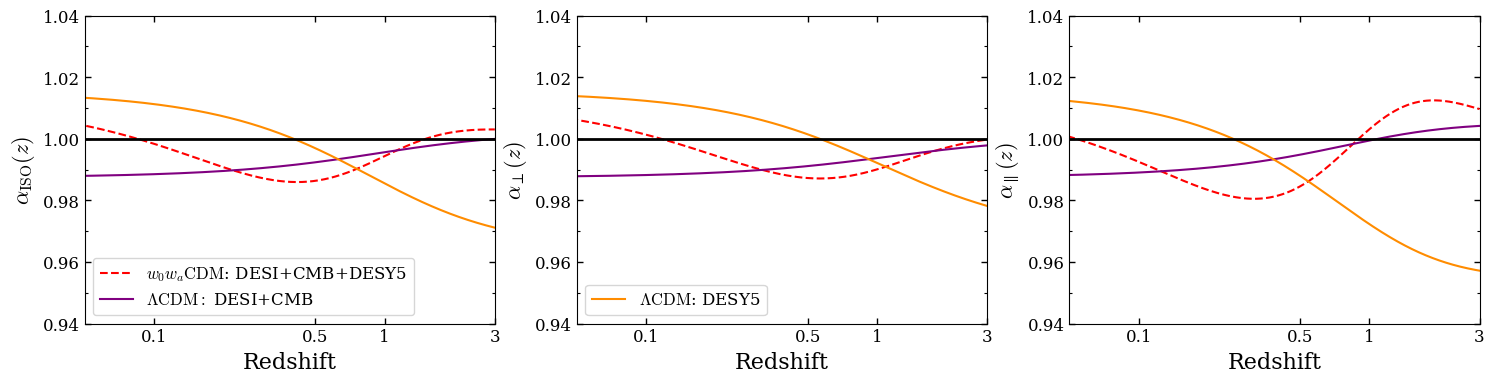

In [33]:
# subplots
fig, axes = plt.subplots(1, 3,figsize=(18, 4))

xlimits = [(0.05, 3) for _ in range(3)]

############ fig 1 alpha ISO #################
axes[0].plot(z, alph_ISO[0], color='r', ls='--', label=r'$w_0 w_a \mathrm{CDM}$: '+'DESI+CMB+DESY5')
axes[0].plot(z, alph_ISO[1], color='purple', ls='-', label=r'$\Lambda \mathrm{CDM}:$ DESI'+'+CMB')
axes[0].plot(z, alph_ISO[2], color='darkorange', ls='-')

axes[0].set_xscale('log')

axes[0].tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
axes[0].tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
axes[0].xaxis.set_minor_locator(AutoMinorLocator())
axes[0].yaxis.set_minor_locator(AutoMinorLocator(2))
axes[0].set_xticks([0.02, 0.1, 0.5, 1, 3])
axes[0].set_xticklabels(['0.02', '0.1', '0.5', '1', '3'])

axes[0].set_ylim(0.94, 1.04)
axes[0].set_xlim(xlimits[0])

axes[0].set_xlabel('Redshift', fontsize=16)
axes[0].set_ylabel(r'$\alpha_\mathrm{ISO}(z)$', fontsize=16)
axes[0].axhline(1, color='k', ls='-', lw=2)
axes[0].legend(loc='lower left', fontsize=12)

############ fig 2 alpha perp #################
axes[1].plot(z, alph_perp[0], color='r', ls='--')
axes[1].plot(z, alph_perp[1], color='purple', ls='-')
axes[1].plot(z, alph_perp[2], color='darkorange', ls='-', label=r'$\Lambda \mathrm{CDM}$: '+'DESY5')

axes[1].set_xscale('log')

axes[1].tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
axes[1].tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
axes[1].xaxis.set_minor_locator(AutoMinorLocator())
axes[1].yaxis.set_minor_locator(AutoMinorLocator(2))
axes[1].set_xticks([0.02, 0.1, 0.5, 1, 3])
axes[1].set_xticklabels(['0.02', '0.1', '0.5', '1', '3'])

axes[1].set_ylim(0.94, 1.04)
axes[1].set_xlim(xlimits[1])

axes[1].set_xlabel('Redshift', fontsize=16)
axes[1].set_ylabel(r'$\alpha_\perp(z)$', fontsize=16)
axes[1].axhline(1, color='k', ls='-', lw=2)
axes[1].legend(loc='lower left', fontsize=12)

# ############ fig 3 alpha parallel #################
axes[2].plot(z, alph_par[0], ls='--', color='r')
axes[2].plot(z, alph_par[1], color='purple', ls='-')
axes[2].plot(z, alph_par[2], color='darkorange', ls='-')

axes[2].set_xscale('log')

axes[2].tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
axes[2].tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
axes[2].xaxis.set_minor_locator(AutoMinorLocator())
axes[2].yaxis.set_minor_locator(AutoMinorLocator(2))
axes[2].set_xticks([0.02, 0.1, 0.5, 1, 3])
axes[2].set_xticklabels(['0.02', '0.1', '0.5', '1', '3'])

axes[2].set_ylim(0.94, 1.04)
axes[2].set_xlim(xlimits[2])

axes[2].set_xlabel('Redshift', fontsize=16)
axes[2].set_ylabel(r'$\alpha_\parallel(z)$', fontsize=16)
axes[2].axhline(1, color='k', ls='-', lw=2)

# plt.savefig(r'..\..\figures\degen_line\alpha_ratio\paper_comparison.png', dpi=300, bbox_inches='tight')

## suite

In [34]:
import camb

def get_Om_hrdrag(w0, wa):

    pars = camb.CAMBparams()

    pars.set_dark_energy(w= w0, wa=wa, dark_energy_model='ppf') # needs to be set before cosmology for shooting to work
    o_b = 0.02223
    o_c = 0.14208 - o_b # values from early CMB priors as in Appendix A of DESI DR2 paper
    pars.set_cosmology(
        thetastar=0.01041, 
        ombh2=o_b, 
        omch2=o_c, 
        H0=None     # camb will complain if we don't specify H0, but it will be computed from thetastar and the densities
    )

    results = camb.get_results(pars)

    h = pars.h
    # H0 = pars.H0
    omega_m = pars.ombh2 + pars.omch2
    Omega_m = omega_m / (h**2)

    # print(f"--- Résultats Directs CAMB ---")
    # print(f"H0 trouvé par shooting : {H0:.2f} km/s/Mpc")
    # print(f"h calculé              : {h:.6f}")
    # print(f"Omega_m dérivé         : {Omega_m:.4f}")

    derived = results.get_derived_params()

    # rs_star = derived['rstar']   # at recombination (z_*)
    rd = derived['rdrag']        # at drag epoch (z_drag)
    h_rd = rd * h                # in Mpc/h

    # print(f"--- Valeurs de l'horizon sonore ---")
    # print(f"rs (recombinaison) : {rs_star:.2f} Mpc")
    # print(f"r_drag             : {rd:.2f} Mpc")
    # print(f"r_drag * h         : {h_rd:.2f} Mpc/h")

    return Omega_m, h_rd
    

In [35]:
def alpha_perp_parallel_alt(z, cosmo_params):
    '''
    alpha_perp = (DM(z)/rd) / (DM_fid(z)/rd_fid)
    alpha_parallel = (DH(z)/rd) / (DH_fid(z)/rd_fid)
    fid --> flat Planck 2018 LCDM
    '''
    fid_planck = cosmoprimo.fiducial.Planck2018FullFlatLCDM()
    fid_bkg = fid_planck.get_background(engine='camb')
    fid_thermo = fid_planck.get_thermodynamics()
    rdrag_fid = fid_thermo.rs_drag
    DM_fid = fid_bkg.comoving_angular_distance(z)
    DH_fid = 1 / fid_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (z * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid

###########################################################
    w0, wa, omm, hrdrag = cosmo_params
    # Omega_cdm_new = och2 / h**2
    # Omega_b_new = obh2 / h**2

    real_cosmo = cosmoprimo.Cosmology(Omega_m=omm, w=w0, wa=wa)
    # print(real_cosmo._params)
    # print(real_cosmo['h'], real_cosmo['Omega_cdm'], real_cosmo['Omega_m'], real_cosmo['Omega_b'], real_cosmo['w0_fld'], real_cosmo['wa_fld'])
    real_bkg = real_cosmo.get_background(engine='camb')
    # real_thermo = real_cosmo.get_thermodynamics()
    # rdrag_real = real_thermo.rs_drag
    DM_real = real_bkg.comoving_angular_distance(z)
    DH_real = 1 / real_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_real = (z * DM_real**2 * DH_real)**(1/3)
    DMover_rd_real = DM_real / hrdrag
    DHover_rd_real = DH_real / hrdrag
    DVover_rd_real = DV_real / hrdrag
    
    return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid
    # return DMover_rd_real, DMover_rd_fid, DHover_rd_real, DHover_rd_fid, DVover_rd_real, DVover_rd_fid

In [36]:
path = r'C:\EPFL\MA4\code\cobaya_runs\DESI_data\base_w_wa\run1'
gd_sample = load_samples(path, to_getdist=True, skip=0.33)
var_names = ['hrdrag', 'omm', 'w', 'wa']

mean_w  = gd_sample.mean('w')
mean_wa = gd_sample.mean('wa')
mean_omm = gd_sample.mean('omm')
mean_hrdrag = gd_sample.mean('hrdrag')

cov_w_omm = gd_sample.cov(pars=['w', 'omm'])
cov_w_hrdrag = gd_sample.cov(pars=['w', 'hrdrag'])

gaussian_grid_w_omm = np.random.multivariate_normal(mean=[mean_w, mean_omm], cov=cov_w_omm, size=10000)
gaussian_grid_w_hrdrag = np.random.multivariate_normal(mean=[mean_w, mean_hrdrag], cov=cov_w_hrdrag, size=10000)
from scipy.optimize import curve_fit
def f(x, a, b):
    return a * x + b

popt_omm, pcov_omm = curve_fit(f, gaussian_grid_w_omm[:, 0], gaussian_grid_w_omm[:, 1])
popt_hrdrag, pcov_hrdrag = curve_fit(f, gaussian_grid_w_hrdrag[:, 0], gaussian_grid_w_hrdrag[:, 1])

slope_omm = popt_omm[0]
intercept_omm = popt_omm[1]
slope_hrdrag = popt_hrdrag[0]
intercept_hrdrag = popt_hrdrag[1]

In [ ]:
from matplotlib.offsetbox import AnchoredText

def plot_alpha_ratios_alt(z, w0, slope, offset, save=False, name=''):
    alph_perp = []
    alph_par = []
    # alph_AP = []
    alph_ISO = []

    for i in range(len(w0)):
        wa = slope * ( w0[i] + offset)
        # Omegam, hrdrag = get_Om_hrdrag(w0[i], wa)
        # wa = -0.86
        # Omegam = 0.3191
        # hrdrag = 97.8
        Omegam = slope_omm * w0[i] + intercept_omm
        hrdrag = slope_hrdrag * w0[i] + intercept_hrdrag
        print(f"w0: {w0[i]:.2f}, wa: {wa:.2f}, Omega_m: {Omegam:.4f}, hrdrag: {hrdrag:.2f}")

        a, b, c = alpha_perp_parallel_alt(z, (w0[i], wa, Omegam, hrdrag)) # w0, wa, obh2, och2, h, hrdrag = cosmo_params
        alph_perp.append(a)
        alph_par.append(b)
        # alph_AP.append(b/a)
        alph_ISO.append(c)

    cmap = cm.coolwarm  # or any other: viridis, plasma, RdBu, etc.
    norm = mcolors.Normalize(vmin=w0.min(), vmax=w0.max())

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    print(len(w0))
    mask = 20
    for i in range(len(w0[:mask])):
        axes[0].plot(z, alph_ISO[i], color=cmap(norm(w0[i])))
        axes[1].plot(z, alph_perp[i], color=cmap(norm(w0[i])))
        axes[2].plot(z, alph_par[i], color=cmap(norm(w0[i])))

    # colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=axes[2], label=r'$w_0$')
    cbar.set_label(r'$w_0$', size=18, rotation=0, va='center', labelpad=10)
    cbar.ax.tick_params(labelsize=11)

    text = AnchoredText(rf'$w_a = {slope:.2f}(w_0 + {offset:.1f})$', 
                        loc='upper right', frameon=True,
                        prop=dict(size=18))
    axes[0].add_artist(text)

    for i in range(len(axes)): 
        axes[i].tick_params(which='major', direction='in', length=4, width=1, top=True, right=True)
        axes[i].tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
        axes[i].xaxis.set_minor_locator(AutoMinorLocator())
        axes[i].yaxis.set_minor_locator(AutoMinorLocator())
        axes[i].set_xlabel('Redshift')
        axes[i].axhline(1, color='k', ls='-', lw=2)
        axes[i].set_xlim(0.02, 3)
        axes[i].set_xscale('function', functions=(
            lambda x: np.log10(0.1+x), lambda x: 10**x-0.1))
        ticks = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3]
        labels = [str(tick) for tick in ticks]
        labels = [tick if tick in ['0.02', '0.1', '0.5', '1', '3'] else '' for tick in labels]
        axes[i].set_xticks(ticks, labels)
    
    axes[0].set_ylabel(r'$\alpha_\mathrm{ISO}(z)$', fontsize=18)
    axes[1].set_ylabel(r'$\alpha_\perp(z)$', fontsize=18)
    axes[2].set_ylabel(r'$\alpha_\parallel(z)$', fontsize=18)
    plt.tight_layout()
    
    if save:
        plt.savefig(rf'..\..\figures\degen_line\alpha_ratio\alpha_ratios_{slope:.2f}_{offset:.1f}_{name}.png', bbox_inches='tight', dpi=300)

w0: -0.75, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80


C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\878536595.py:36: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


w0: -0.75, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
2


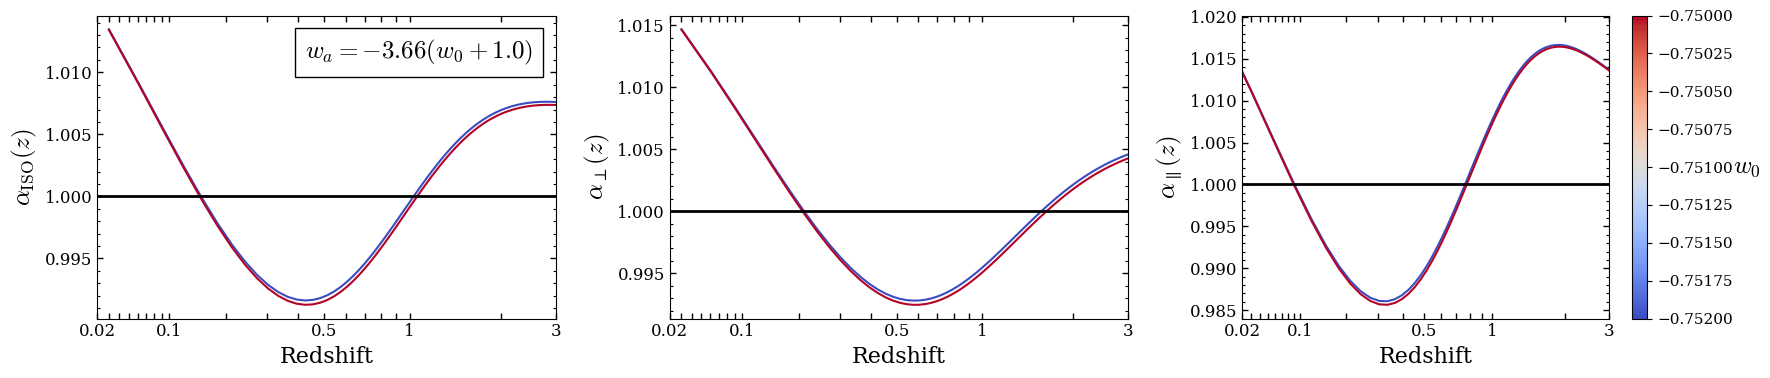

In [43]:
z = np.linspace(0.0, 3.0, 100)
# a, b, c = alpha_perp_parallel(z, (-1.0, 0.0, 0.2975, 100))

w0 = np.linspace(-1, 0, 10)
w0 = np.linspace(-0.752, -0.75, 2)
# w0 = np.linspace(-1, w0_max*1.05, 10)
offset = 1
slope = -3.66

plot_alpha_ratios_alt(z, w0, slope, offset)#, save=True)#, name='zoom_broader')

w0 max: -0.7
w0: -0.65, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.58, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80


C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\878536595.py:36: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


w0: -0.51, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.44, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.36, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.29, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.22, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.15, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.07, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: 0.00, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
10


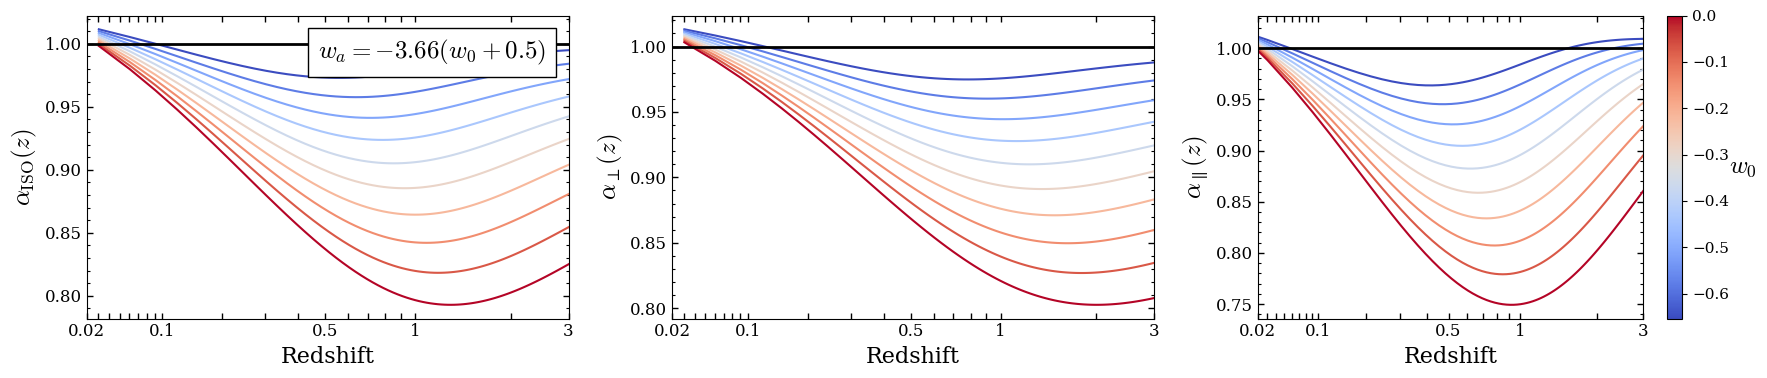

In [39]:
slope = -3.66
offset = 0.5
w0_max = -(slope*offset) / (slope + 1)
w0 = np.linspace(0.95*w0_max, 0, 10)
wa_ = slope * ( w0 + offset)

print(f"w0 max: {w0_max:.1f}")

# print([wa_[i] + w0[i] for i in range(len(w0))])

plot_alpha_ratios_alt(z, w0, slope, offset)#, save=True, name='par')

w0 max: -0.8
w0: -1.00, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.98, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80


C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\878536595.py:36: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


w0: -0.95, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.93, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.91, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.89, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.86, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.84, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.82, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.79, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
10


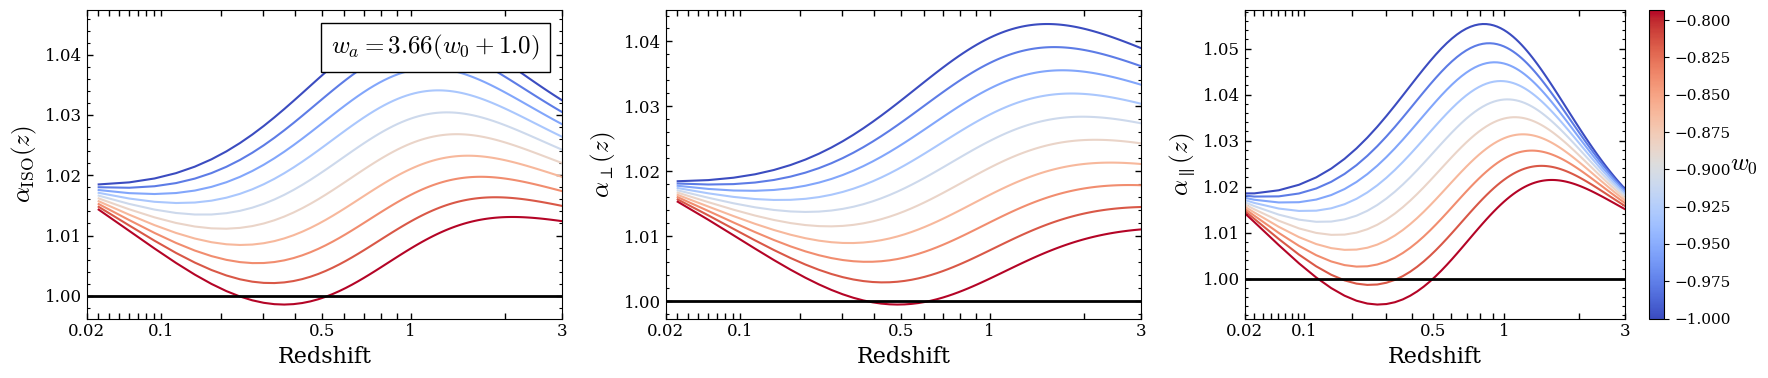

In [40]:
slope = 3.66
offset = 1
w0_max = -(slope*offset) / (slope + 1)
w0 = np.linspace(-1, w0_max*1.01, 10)
wa_ = slope * ( w0 + offset)

print(f"w0 max: {w0_max:.1f}")

# print([wa_[i] + w0[i] for i in range(len(w0))])

plot_alpha_ratios_alt(z, w0, slope, offset)#, save=True, name='perp')

w0 max: 0.0
w0: -1.00, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.89, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.78, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80


C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\878536595.py:36: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


w0: -0.67, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.56, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.44, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.33, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.22, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.11, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: 0.00, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
10


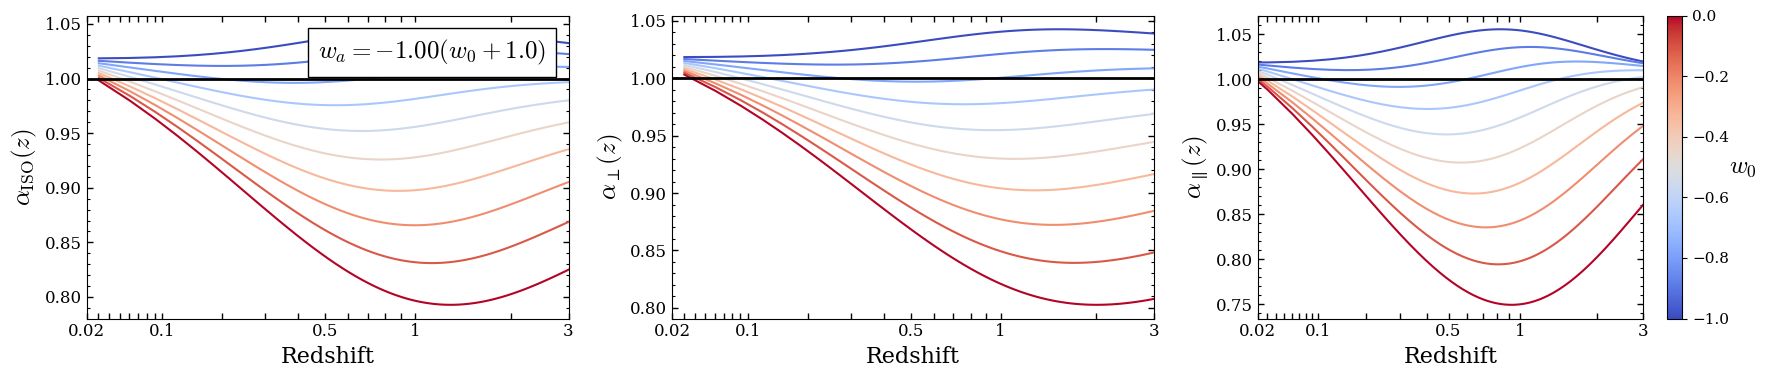

In [41]:
slope = -1 # NEC line
offset = 1
# w0_max = -(slope*offset) / (slope + 1) # no intersection, NEC line is parallel to w0+wa=0 line
w0_max = 0
w0 = np.linspace(-1, w0_max, 10)
wa_ = slope * ( w0 + offset)

print(f"w0 max: {w0_max:.1f}")

# print([wa_[i] + w0[i] for i in range(len(w0))])

plot_alpha_ratios_alt(z, w0, slope, offset)#, save=True, name='NEC')

w0 max: -1.3
w0: -1.00, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.89, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.78, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80


C:\Users\adrie\AppData\Local\Temp\ipykernel_13212\878536595.py:36: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


w0: -0.67, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.56, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.44, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.33, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.22, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: -0.11, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
w0: 0.00, wa: -0.86, Omega_m: 0.3191, hrdrag: 97.80
10


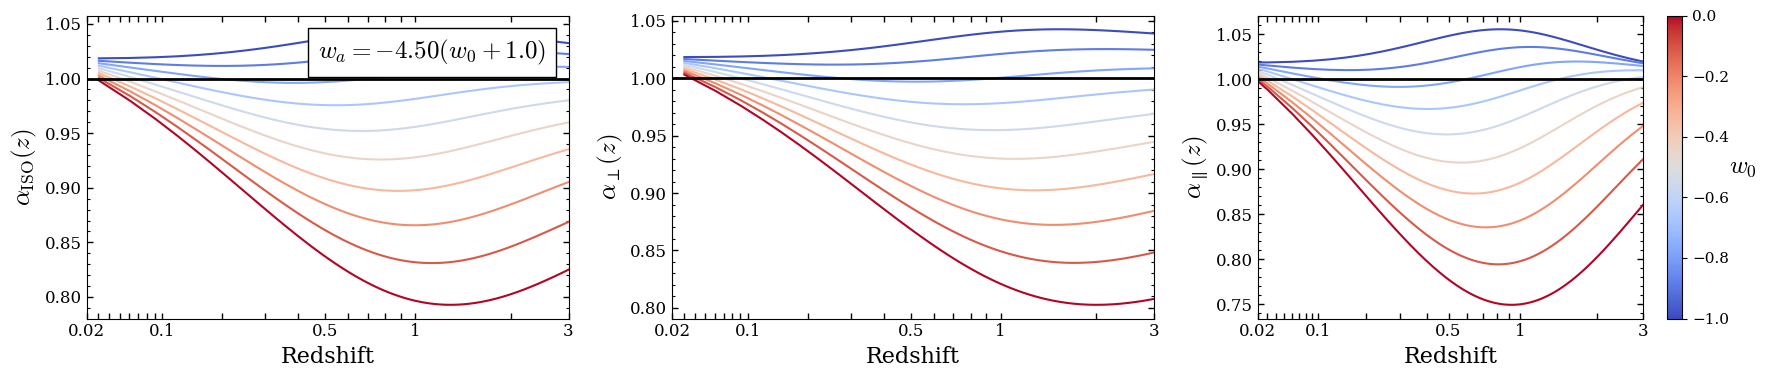

In [42]:
slope = -4.5 
offset = 1
w0_max = -(slope*offset) / (slope + 1) # no intersection, NEC line is parallel to w0+wa=0 line
# w0_max = 0
w0 = np.linspace(-1, 0, 10)
wa_ = slope * ( w0 + offset)

print(f"w0 max: {w0_max:.1f}")

# print([wa_[i] + w0[i] for i in range(len(w0))])

plot_alpha_ratios_alt(z, w0, slope, offset)#, save=True, name='NEC')

# brouillon

In [141]:
import camb     # forced to use camb because cosmoprimo and camb get mixed up in their errors about setting thetastar and h

pars = camb.CAMBparams()

pars.set_dark_energy(w= -0.75, wa=-0.86, dark_energy_model='ppf') # needs to be set before cosmology for shooting to work

pars.set_cosmology(
    thetastar=0.0104092, 
    ombh2=0.02237, 
    omch2=0.1200, 
    H0=None     # camb will complain if we don't specify H0, but it will be computed from thetastar and the densities
)

results = camb.get_results(pars)

h = pars.h
H0 = pars.H0
omega_m = pars.ombh2 + pars.omch2
Omega_m = omega_m / (h**2)

print(f"--- Résultats Directs CAMB ---")
print(f"H0 trouvé par shooting : {H0:.2f} km/s/Mpc")
print(f"h calculé              : {h:.6f}")
print(f"Omega_m dérivé         : {Omega_m:.4f}")


--- Résultats Directs CAMB ---
H0 trouvé par shooting : 66.50 km/s/Mpc
h calculé              : 0.664971
Omega_m dérivé         : 0.3220


In [142]:
derived = results.get_derived_params()

rs_star = derived['rstar']   # at recombination (z_*)
rd = derived['rdrag']        # at drag epoch (z_drag)
h_rd = rd * h                # in Mpc/h

print(f"--- Valeurs de l'horizon sonore ---")
print(f"rs (recombinaison) : {rs_star:.2f} Mpc")
print(f"r_drag             : {rd:.2f} Mpc")
print(f"r_drag * h         : {h_rd:.2f} Mpc/h")


--- Valeurs de l'horizon sonore ---
rs (recombinaison) : 144.44 Mpc
r_drag             : 147.10 Mpc
r_drag * h         : 97.82 Mpc/h


In [ ]:
# lax[i].set_xscale('function', functions=(
#             lambda x: np.log10(0.1+x), lambda x: 10**x-0.1))
#         ticks = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3]
#         labels = [str(tick) for tick in ticks]
#         labels = [tick if tick in ['0.02', '0.1', '0.5', '1', '3'] else '' for tick in labels]
#         lax[i].set_xticks(ticks, labels)

In [4]:
def slope_of_cst_energy_density(z):
    return -3 * (1 + z) / (2 + 3 * z)

In [12]:
z_test = np.linspace(0.1, 1, 10)
slopes = slope_of_cst_energy_density(z_test)

(-2.5, 0.1)

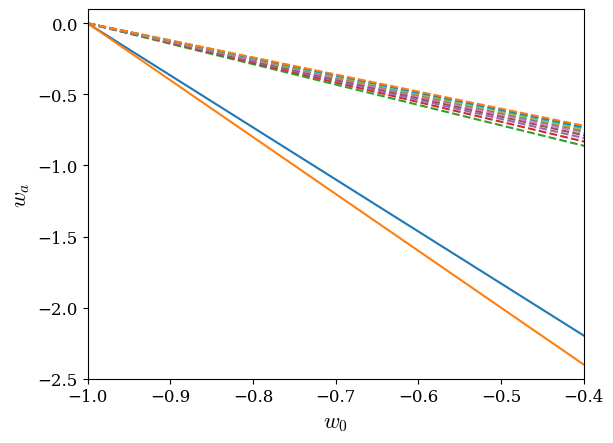

In [14]:
x = np.linspace(-1, 0, 10)
y = -3.66 * (x + 1)
plt.plot(x, y)
y = -4 * (x + 1)
plt.plot(x, y)
for s in slopes:
    y = s * (x + 1)
    plt.plot(x, y, ls='--')
plt.xlabel('$w_0$')
plt.ylabel('$w_a$')    
plt.xlim(-1, -0.4)
plt.ylim(-2.5, 0.1)

In [103]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def sign_drhodz(z, w0, wa):
    """Sign of dρ/dz for CPL dark energy: 3(1+w0+wa)(1+z) - wa"""
    return 3 * (1 + w0 + wa) * (1 + z) - wa

# --- 1D plot: sign as a function of z for fixed w0, wa ---
def plot_1d(w0=-0.9, wa=0.1, z_max=3.0):
    z = np.linspace(0, z_max, 500)
    f = sign_drhodz(z, w0, wa)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.fill_between(z, f, 0, where=(f >= 0), color='teal',  alpha=0.3, label='NEC satisfied')
    ax.fill_between(z, f, 0, where=(f <  0), color='coral', alpha=0.3, label='NEC violated')
    ax.plot(z, f, color='steelblue', lw=2)

    # zero crossing
    A = 3 * (1 + w0 + wa)
    B = 3 * (1 + w0 + wa) - wa
    if abs(A) > 1e-10:
        z_star = -B / A
        if 0 <= z_star <= z_max:
            ax.axvline(z_star, color='gray', ls=':', lw=1.2,
                       label=f'$z^* = {z_star:.2f}$')

    ax.set_xlabel('redshift $z$', fontsize=13)
    ax.set_ylabel(r'$3(1+w_0+w_a)(1+z) - w_a$', fontsize=13)
    ax.set_title(f'Sign of $d\\rho_{{DE}}/dz$,  $w_0={w0}$,  $w_a={wa}$', fontsize=13)
    ax.legend()
    plt.tight_layout()
    # plt.savefig('drhodz_sign_1d.pdf')
    plt.show()

# --- 2D plot: sign in (w0, wa) plane for fixed z ---
def plot_2d(z=0.0, n=400):
    w0 = np.linspace(-2, 0, n)
    wa = np.linspace(-2, 2, n)
    W0, WA = np.meshgrid(w0, wa)
    F = sign_drhodz(z, W0, WA)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.contourf(W0, WA, F, levels=[F.min(), 0, F.max()],
                colors=['coral', 'teal'], alpha=0.4)
    ax.contour(W0, WA, F, levels=[0], colors='k', linewidths=1.2)

    # cosmological constant
    ax.plot(-1, 0, 'k+', ms=10, label=r'$\Lambda$CDM ($w_0=-1, w_a=0$)')

    ax.set_xlabel('$w_0$', fontsize=13)
    ax.set_ylabel('$w_a$', fontsize=13)
    ax.set_title(f'NEC violation in $(w_0, w_a)$ plane at $z={z}$', fontsize=13)
    ax.legend(fontsize=10)

    from matplotlib.patches import Patch
    legend_els = [Patch(facecolor='teal',  alpha=0.5, label='NEC satisfied'),
                  Patch(facecolor='coral', alpha=0.5, label='NEC violated')]
    ax.legend(handles=legend_els + ax.get_legend_handles_labels()[0][0:1], fontsize=10)

    plt.tight_layout()
    # plt.savefig(f'drhodz_sign_2d_z{z}.pdf')
    plt.show()

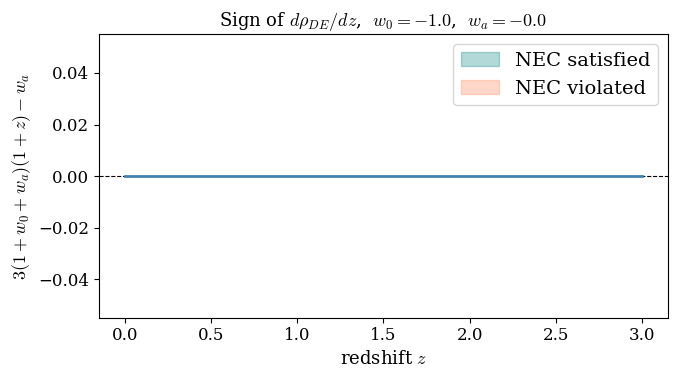

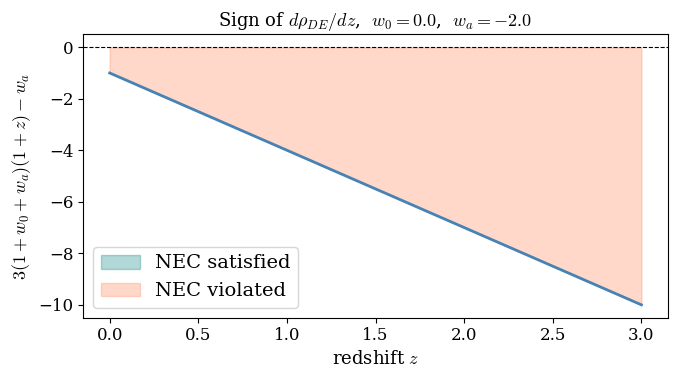

In [53]:
slope = -2
w0 = np.linspace(-1, 0, 2)
wa = slope * (w0 + 1)
for i in range(len(w0)):
    plot_1d(w0=w0[i], wa=wa[i])
# plot_1d(w0=-0.9, wa=-0.12)
# plot_2d(z=0.0)
# plot_2d(z=1.0)
# plot_2d(z=2.0)

In [ ]:
def w(w0, wa, z):
    return w0 + wa * z

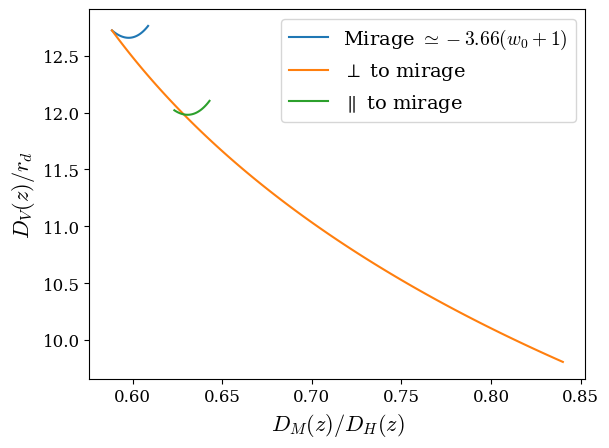

In [41]:
k = 0 # redshift index

lines = [-3.66, 3.66, -3.66] # mirage and perpandicular to mirage
offsets = [1, 1, 0.5]
labels = [r'Mirage $\simeq -3.66 (w_0 + 1)$', r'$\perp$ to mirage', r'$\parallel$ to mirage']
for idx, slope in enumerate(lines):
    DMoverDH, DVover_rd, _ = distances_ratio(slope, offset=offsets[idx])
    plt.plot(DMoverDH[:, k], DVover_rd[:, k], label=labels[idx])
plt.xlabel(r'$D_M(z)/D_H(z)$')
plt.ylabel(r'$D_V(z)/r_d$')
plt.legend()


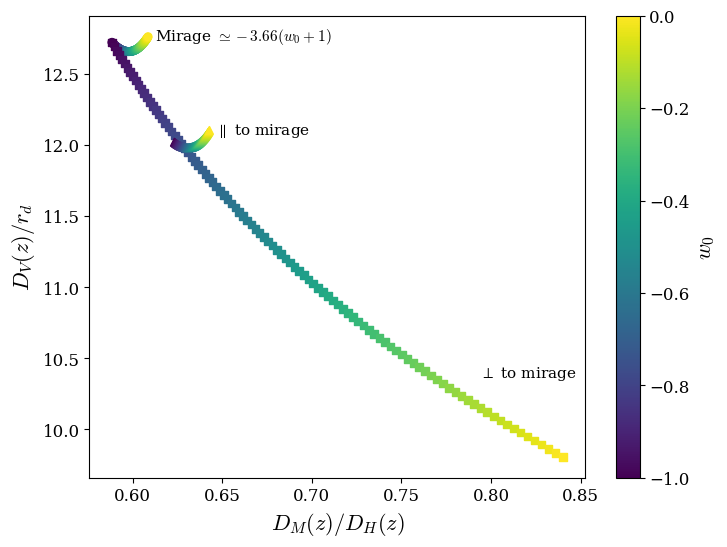

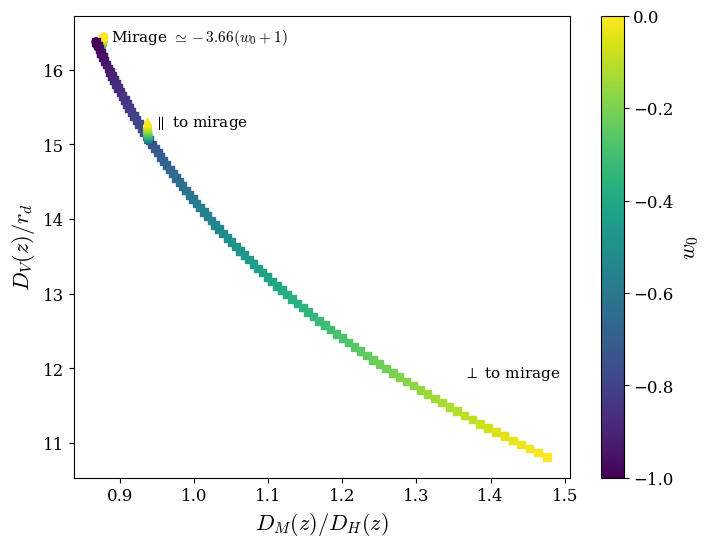

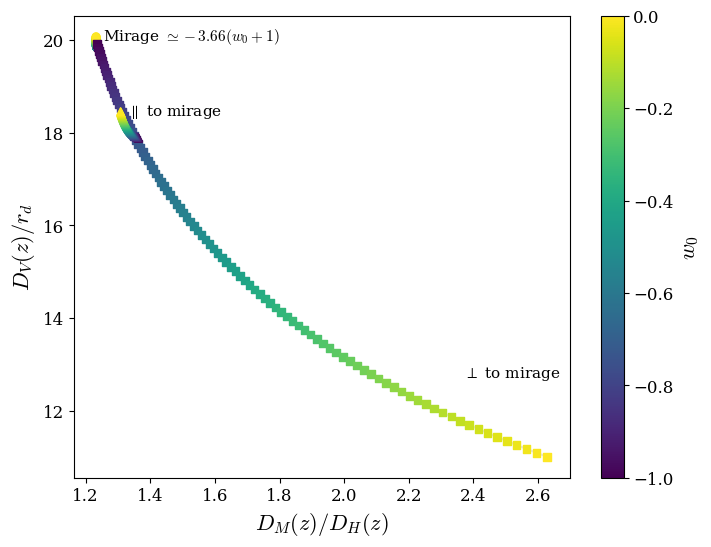

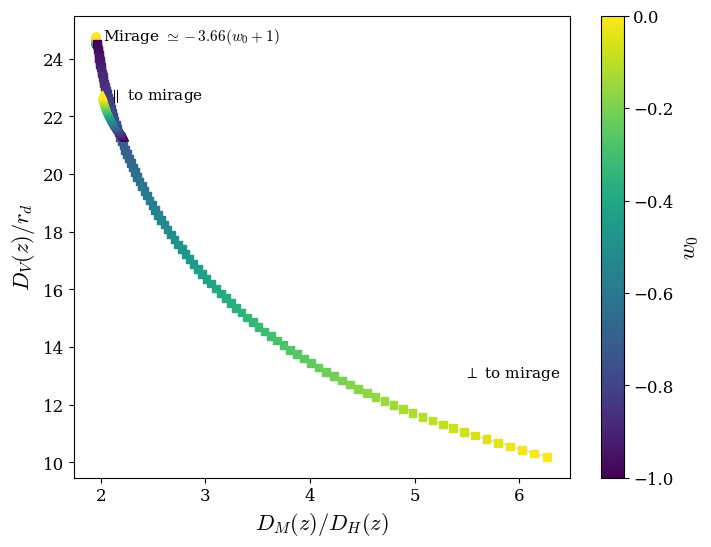

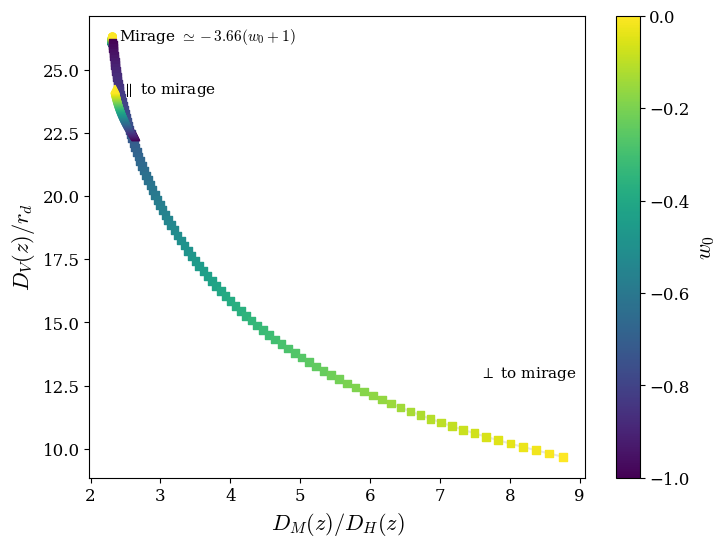

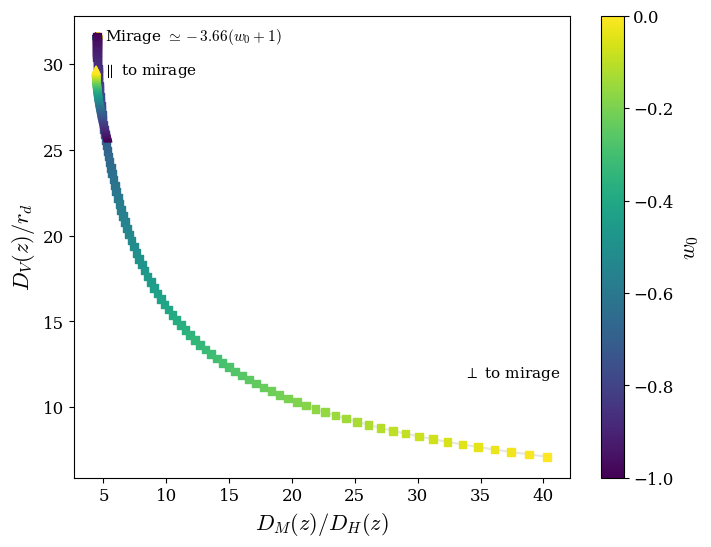

In [42]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

k = 1  # redshift index
for k in range(6):
    lines = [-3.66, 3.66, -3.66]
    offsets = [1, 1, 0.5]
    labels = [r'Mirage $\simeq -3.66 (w_0 + 1)$', r'$\perp$ to mirage', r'$\parallel$ to mirage']

    # Define colormap and normalization — adjust vmin/vmax to your w0 range
    norm = Normalize(vmin=-1, vmax=0)
    cmap = plt.cm.viridis

    fig, ax = plt.subplots(figsize=(8, 6))

    markers = ['o', 's', '^']  # circle, square, triangle
    # markers_sie = [10, 30, 10]  # marker sizes for better visibility
    text_offsets = [(5, 0), (-60, 60), (5, 0)]  # tune these to avoid overlap

    for idx, (slope, marker) in enumerate(zip(lines, markers)):
        DMoverDH, DVover_rd, w0_values = distances_ratio(slope, offset=offsets[idx])
        
        ax.plot(DMoverDH[:, k], DVover_rd[:, k], color='gray', alpha=0.2)
        ax.scatter(DMoverDH[:, k], DVover_rd[:, k],
                c=w0_values, cmap=cmap, norm=norm,
                s=30, marker=marker, zorder=3)
        
        ax.annotate(labels[idx],
                    xy=(DMoverDH[-1, k], DVover_rd[-1, k]),
                    xytext=text_offsets[idx],
                    textcoords='offset points',
                    fontsize=11,
                    va='center')

    fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, label=r'$w_0$')
    ax.set_xlabel(r'$D_M(z)/D_H(z)$')
    ax.set_ylabel(r'$D_V(z)/r_d$')
    plt.show()